Profiles `cleaned_sections.json` **before chunking**, so chunking parameters are chosen from the data rather than guessed. 

Produces:
- token / char / word length distributions per section (headline: token histogram)
- chunking preview (how many sections split, estimated total chunks)
- integrity checks (empty sections, duplicates, metadata completeness, noise)
- structure (level + per-chapter distribution, page coverage)
- language detection (validates the multilingual bge-m3 choice)
- boilerplate term check

## 0. Setup

In [25]:
import json
from pathlib import Path
from collections import Counter
import re

import pandas as pd
import matplotlib.pyplot as plt

from transformers import AutoTokenizer

from langdetect import detect, DetectorFactory

import nltk
from nltk.corpus import stopwords

In [ ]:
# bge-m3 native context is 8192 tokens

# Chunking Baseline Model Config
INTENDED_CHUNK_SIZE = 500     # tokens per chunk
NEAR_EMPTY_CHARS    = 30      # sections shorter than this are suspect
EMBEDDING_MODEL     = "BAAI/bge-m3"

In [27]:
DATA_PATH = Path("../../data/processed/cleaned_sections.json")

## 1. Load into a DataFrame

In [28]:
with open(DATA_PATH, encoding="utf-8") as f:
    sections = json.load(f)

df = pd.DataFrame(sections)

print(f"{len(df)} sections")
df.head()

63 sections


,level,number,title,chapter_number,chapter_title,section_number,section_title,page_start,page_end,text
0,chapter,1,INTRODUÇÃO,1,INTRODUÇÃO,NaN,NaN,20,20,Neste capítulo será realizado o enquadramento ...
1,section,1.1,Enquadramento,1,INTRODUÇÃO,NaN,NaN,20,21,As empresas do setor de retalho alimentar ofer...
2,section,1.2,Objetivos,1,INTRODUÇÃO,NaN,NaN,21,21,Os principais objetivos deste projeto passam p...
3,section,1.3,Metodologia de Investigação,1,INTRODUÇÃO,NaN,NaN,21,23,Com vista a atingir todos os trabalhos propost...
4,section,1.4,Estrutura da Dissertação,1,INTRODUÇÃO,NaN,NaN,23,24,A presente dissertação encontra-se dividida em...


## 2. Length columns

In [ ]:
# Token counter: bge-m3 tokenizer
try:
    tokenizer = AutoTokenizer.from_pretrained(EMBEDDING_MODEL)

    def count_tokens(t):
        return len(tokenizer.encode(t, add_special_tokens=False))

except Exception as e:
    print("BGE-M3 tokenizer unavailable", repr(e))

# Profiling columns
df["char_count"]  = df["text"].str.len()
df["word_count"]  = df["text"].str.split().map(len)
df["token_count"] = df["text"].map(count_tokens)

print("tokenizer:", EMBEDDING_MODEL)
df[["number","title","level","page_start","page_end","char_count","word_count","token_count"]].head()

tokenizer: BAAI/bge-m3


,number,title,level,page_start,page_end,char_count,word_count,token_count
0,1,INTRODUÇÃO,chapter,20,20,291,43,53
1,1.1,Enquadramento,section,20,21,2728,424,617
2,1.2,Objetivos,section,21,21,1240,186,262
3,1.3,Metodologia de Investigação,section,21,23,1870,279,394
4,1.4,Estrutura da Dissertação,section,23,24,2099,308,424


## 3. Summary statistics

In [30]:
stats = df[["token_count","word_count","char_count"]].describe(
    percentiles=[.5,.75,.95]).round(1)
print(stats)

print("\nBy level (token_count):")
print(df.groupby("level")["token_count"].describe()[["count","mean","min","max"]].round(1))

       token_count  word_count  char_count
count         63.0        63.0        63.0
mean         625.3       433.7      2794.7
std          655.0       451.1      2804.6
min           53.0        43.0       291.0
50%          438.0       311.0      1999.0
75%          692.0       486.5      3145.0
95%         2436.0      1662.4     10255.8
max         3023.0      1987.0     12333.0

By level (token_count):
            count   mean    min     max
level                                  
chapter       7.0  425.4   53.0  1599.0
section      23.0  702.1  102.0  2802.0
subsection   33.0  614.2  135.0  3023.0


## 4. Token-length distribution

**This drives `chunk_size`.** What healthy looks like:
- a clear central mass — set `chunk_size` near/below it so most sections actually split into a few coherent chunks
- a left tail near zero = cleaning fragments to investigate
- a long right tail = a few very large sections that will dominate the index

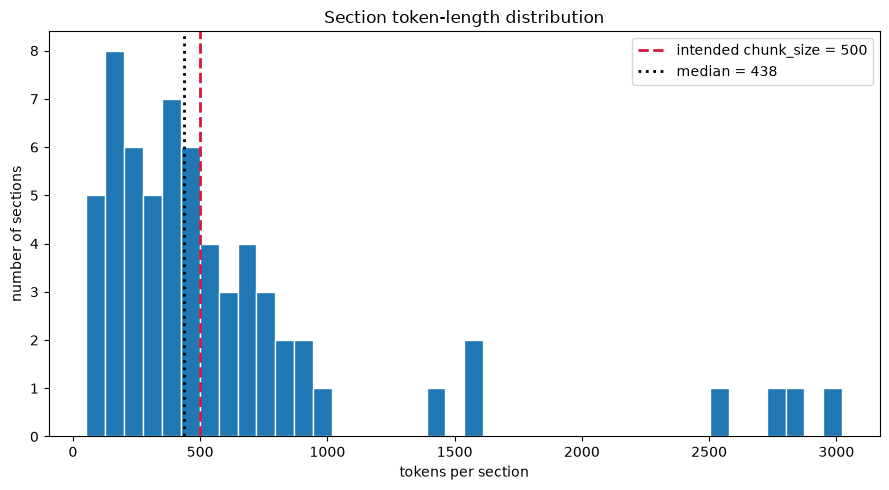

In [31]:
fig, ax = plt.subplots(figsize=(9,5))
ax.hist(
    df["token_count"], 
    bins=40, 
    edgecolor="white"
)
ax.axvline(
    INTENDED_CHUNK_SIZE, 
    color="crimson", 
    ls="--", 
    lw=2,
    label=f"intended chunk_size = {INTENDED_CHUNK_SIZE}"
)
ax.axvline(
    df["token_count"].median(), 
    color="black", 
    ls=":", 
    lw=2,
    label=f"median = {df['token_count'].median():.0f}"
)
ax.set(
    xlabel="tokens per section", 
    ylabel="number of sections",
    title="Section token-length distribution"
)

ax.legend()
fig.tight_layout()

plt.show()

## 5. Chunking preview

In [32]:
# Count how many sections are below and above the intended chunk size
below = (df["token_count"] <= INTENDED_CHUNK_SIZE).sum()
above = (df["token_count"] >  INTENDED_CHUNK_SIZE).sum()

# Estimate assuming ~15% overlap on sections that exceed the target
overlap = 0.15
def est_chunks(tok):
    if tok <= INTENDED_CHUNK_SIZE:
        return 1
    step = INTENDED_CHUNK_SIZE * (1 - overlap)
    return max(1, int(-(-tok // step)))  # ceil
df["est_chunks"] = df["token_count"].map(est_chunks)

print(f"intended chunk_size           : {INTENDED_CHUNK_SIZE} tokens")
print(f"sections NOT split (<= size)  : {below}  ({below/len(df):.0%})")
print(f"sections that WILL split      : {above}  ({above/len(df):.0%})")
print(f"estimated total chunks        : {df['est_chunks'].sum()}")

# Note: if below/len(df) > 0.7, most sections already fit in one chunk - heavy chunking adds little

intended chunk_size           : 500 tokens
sections NOT split (<= size)  : 37  (59%)
sections that WILL split      : 26  (41%)
estimated total chunks        : 119


## 6. Integrity & cleaning quality

In [33]:
# Empty / near-empty texts
near_empty = df[df["char_count"] < NEAR_EMPTY_CHARS]
print(f"empty and/or near-empty (<{NEAR_EMPTY_CHARS} chars): {len(near_empty)}")
if len(near_empty):
    display(near_empty[["number","title","char_count","text"]])

# Metadata completeness — exposes dead keys (e.g. section_number/section_title)
print("\nNull counts per column:")
print(df.isnull().sum())
dead = [c for c in df.columns if df[c].isnull().all()]

print("\nDEAD keys (100% null):", dead or "none")

empty and/or near-empty (<30 chars): 0

Null counts per column:
level              0
number             0
title              0
chapter_number     0
chapter_title      0
section_number    30
section_title     30
page_start         0
page_end           0
text               0
char_count         0
word_count         0
token_count        0
est_chunks         0
dtype: int64

DEAD keys (100% null): none


In [34]:
# Exact + near-duplicate text (repeated headers/footers leaking from extraction)
exact_dups = df["text"].duplicated(keep=False)
print("exact duplicate texts:", exact_dups.sum())
if exact_dups.any():
    display(df.loc[exact_dups, ["number","title","page_start"]])

# Near-dup: compare normalized prefixes
def norm(t): 
    return re.sub(r"\s+"," ", t.strip().lower())[:120]

pref = df["text"].map(norm)
near = pref[pref.duplicated(keep=False)]
print("sections sharing a near-identical opening 120 chars:", near.nunique(), "groups affected" if len(near) else "")

exact duplicate texts: 0
sections sharing a near-identical opening 120 chars: 1 groups affected


In [35]:
# Noise ratios — stray whitespace / non-letter density
def noise_ratio(t):
    if not t: return 0.0
    non_alnum = sum(1 for c in t if not (c.isalnum() or c.isspace()))
    return round(non_alnum / len(t), 3)

df["noise_ratio"] = df["text"].map(noise_ratio)
print("noise_ratio (punctuation/symbols share) — high values worth a look:")
display(df.sort_values("noise_ratio", ascending=False)
          [["number","title","noise_ratio","char_count"]].head(5))

noise_ratio (punctuation/symbols share) — high values worth a look:


,number,title,noise_ratio,char_count
21,3.1,MC Sonae,0.049,1564
11,2.3,Simulação,0.048,2112
19,2.4.3,Guia de Mital para Manuseamento Manual de Mate...,0.044,735
24,3.4,Loja em estudo,0.040,398
7,2.1.1,Casa do Sistema de Produção Toyota,0.039,2683


## 7. Structure & coverage

level distribution: {'subsection': 33, 'section': 23, 'chapter': 7}

sections per chapter:
chapter_title
DESENVOLVIMENTO E MODELAÇÃO DAS OPERAÇÕES DE LOJA                           5
ENQUADRAMENTO DO PROJETO                                                    4
ENQUADRAMENTO TEÓRICO                                                       4
INTERPRETAÇÃO E DISCUSSÃO DOS RESULTADOS OBTIDOS E PROPOSTAS DE MELHORIA    4
INTRODUÇÃO                                                                  4
CONCLUSÃO                                                                   2
dtype: int64


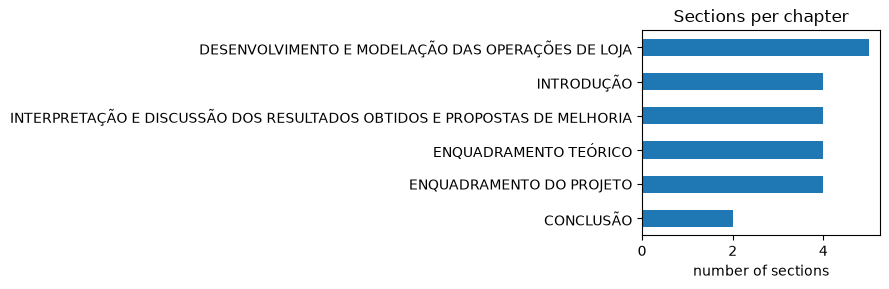

In [36]:
print("level distribution:", df["level"].value_counts().to_dict())

# Sections per chapter — reveals corpus imbalance that would skew retrieval/eval
per_ch = (df[df["level"]=="section"]
          .groupby("chapter_title").size()
          .sort_values(ascending=False))
print("\nsections per chapter:")
print(per_ch)

fig, ax = plt.subplots(figsize=(9, max(3, 0.45*len(per_ch))))
per_ch.sort_values().plot.barh(ax=ax)
ax.set(
    xlabel="number of sections", 
    ylabel="", 
    title="Sections per chapter"
)

fig.tight_layout()

plt.show()

In [37]:
# Page coverage sanity (does the section span look right?)
df["page_span"] = (df["page_end"] - df["page_start"]).clip(lower=0)
print("page span per section — describe:")
print(df["page_span"].describe()[["mean","min","max"]].round(2))
print("multi-page sections:", (df['page_span']>0).sum())

page span per section — describe:
mean     1.86
min      0.00
max     10.00
Name: page_span, dtype: float64
multi-page sections: 50


## 8. Language detection

Validates the bge-m3 (multilingual) choice

In [38]:
try:
    DetectorFactory.seed = 0
    
    def safe_detect(t):
        try: 
            return detect(t) if len(t.strip())>20 else "?"
        except Exception: 
            return "?"
    
    df["lang"] = df["text"].map(safe_detect)
    print(df["lang"].value_counts().to_dict())

except Exception as e:
    print("Error detecting language:", repr(e))

{'pt': 63}


## 9. Boilerplate term check (PT stopwords removed)

In [46]:
# PT_STOP = set('''a o e de do da das dos em no na nos nas um uma para por com que se
# ao aos as os à às e ou como mais já não sua seu suas seus este esta estes estas
# isto isso entre sobre tendo ser foi são será deste desta neste nesta pode forma'''.split())

PT_STOP = stopwords.words('portuguese')

words = re.findall(r"\b[a-záàâãéêíóôõúç]+\b", " ".join(df["text"]).lower())
content = [w for w in words if w not in PT_STOP and len(w) > 2]
top = Counter(content).most_common(25)

print("Top content terms (scan for leftover boilerplate like 'página', 'referências', 'figura'):")
for w,c in top: print(f"  {c:5d}  {w}")

Top content terms (scan for leftover boilerplate like 'página', 'referências', 'figura'):
    180  produtos
    142  paletes
    133  figura
    125  forma
    121  palete
    109  reposição
    103  sistema
    102  modelo
     99  despicking
     93  resultados
     88  cada
     84  processo
     78  desta
     75  loja
     74  atividades
     74  número
     74  cenário
     72  produto
     71  deste
     69  estudo
     66  conta
     66  simulação
     65  processos
     65  trabalho
     62  caso


## 10. Save machine-readable summary

In [47]:
summary = {
    "n_sections": int(len(df)),
    "tokenizer": EMBEDDING_MODEL,
    "intended_chunk_size": INTENDED_CHUNK_SIZE,
    "token_stats": {k: float(v) for k,v in
                    df["token_count"].describe(percentiles=[.5,.95]).round(1).items()},
    "estimated_total_chunks": int(df["est_chunks"].sum()),
    "sections_not_split": int((df["token_count"]<=INTENDED_CHUNK_SIZE).sum()),
    "dead_keys": [c for c in df.columns if df[c].isnull().all()],
    "near_empty_sections": int((df["char_count"]<NEAR_EMPTY_CHARS).sum()),
    "exact_duplicate_texts": int(df["text"].duplicated().sum()),
    "levels": df["level"].value_counts().to_dict(),
    "languages": df["lang"].value_counts().to_dict() if "lang" in df else "not_run",
}
out = Path("profile_summary.json")
out.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")
print(json.dumps(summary, ensure_ascii=False, indent=2))
print("\nsaved ->", out)

{
  "n_sections": 63,
  "tokenizer": "BAAI/bge-m3",
  "intended_chunk_size": 500,
  "token_stats": {
    "count": 63.0,
    "mean": 625.3,
    "std": 655.0,
    "min": 53.0,
    "50%": 438.0,
    "95%": 2436.0,
    "max": 3023.0
  },
  "estimated_total_chunks": 119,
  "sections_not_split": 37,
  "dead_keys": [],
  "near_empty_sections": 0,
  "exact_duplicate_texts": 0,
  "levels": {
    "subsection": 33,
    "section": 23,
    "chapter": 7
  },
  "languages": {
    "pt": 63
  }
}

saved -> profile_summary.json
